In [1]:
from src.baseline_config import build_training_config
import src.training as training
from src.phase0.split import create_baseline_split
from src.phase1.config import PHASE1_RUNS
from src.phase1.experiment import (
    print_phase1_summary,
    run_phase1_experiments,
    show_phase1_plots,
)
from utils.metrics import print_results_metrics_summary

TRAINING_CONFIG = build_training_config(architecture="vit_small")

In [2]:
train_df, validation_df = create_baseline_split(overwrite=False)

print("Train class distribution:")
print(training.get_class_counts(train_df).to_string())
print(sum(training.get_class_counts(train_df)))

print("\nValidation class distribution:")
print(training.get_class_counts(validation_df).to_string())
print(sum(training.get_class_counts(validation_df)))

Train class distribution:
histology
Adenoma                     1578
Sessile_serrated_adenoma     725
Hyperplastic                 334
Adenocarcinoma               101
2738

Validation class distribution:
histology
Adenoma                     395
Sessile_serrated_adenoma    182
Hyperplastic                 84
Adenocarcinoma               19
680


In [3]:
run_phase1_experiments(training_config=TRAINING_CONFIG, force_train=False)

Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase1\seed1\best_baseline_model.pth


c:\Users\luis\Documents\TFG - Data-Centric AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase1\seed2\best_baseline_model.pth


Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase1\seed3\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase1\seed4\best_baseline_model.pth


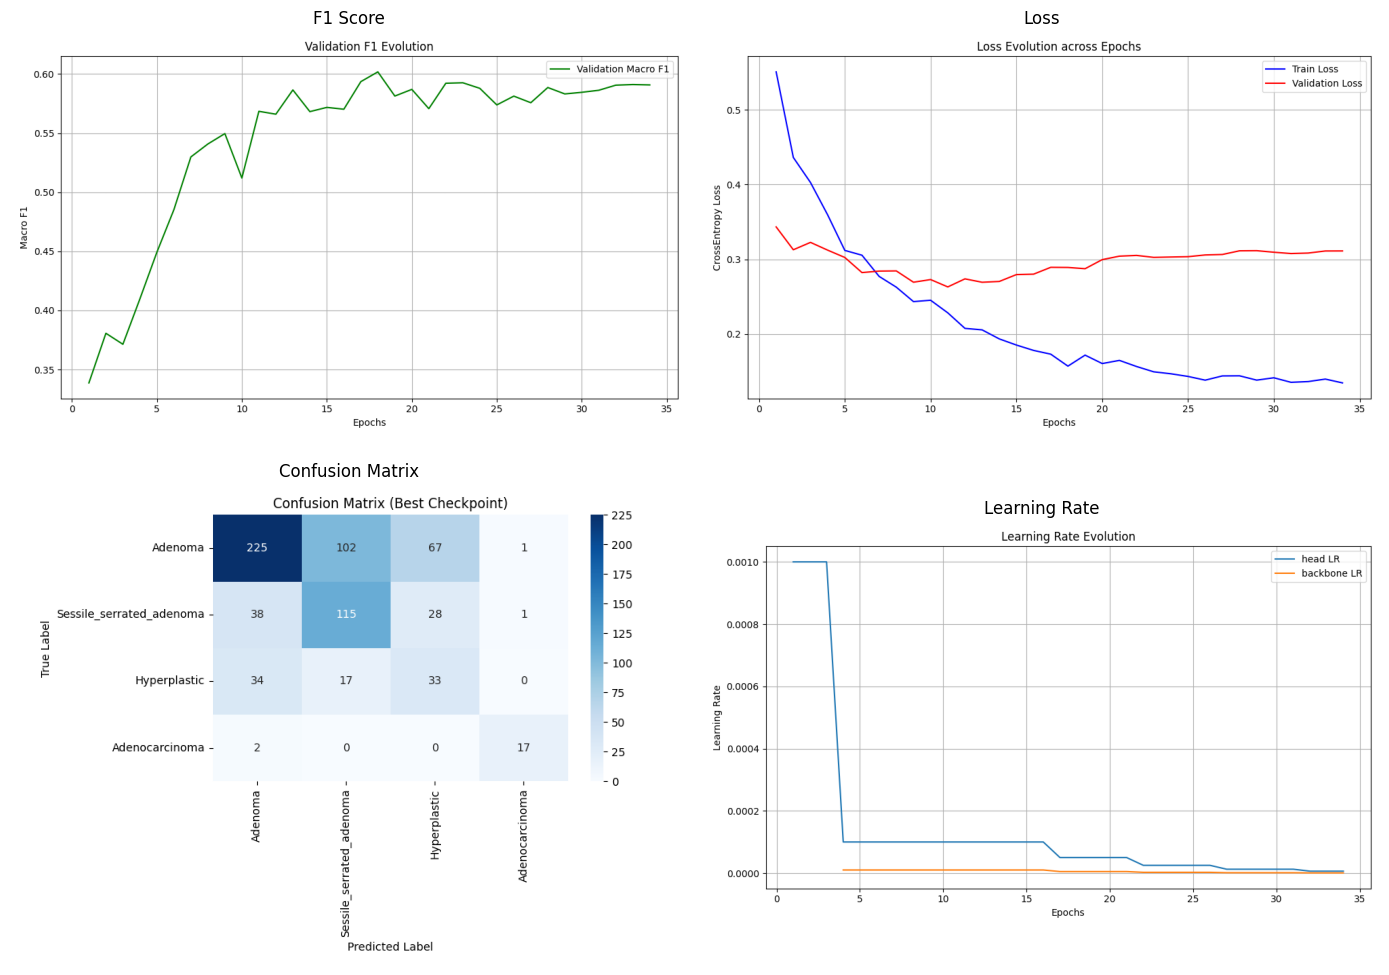

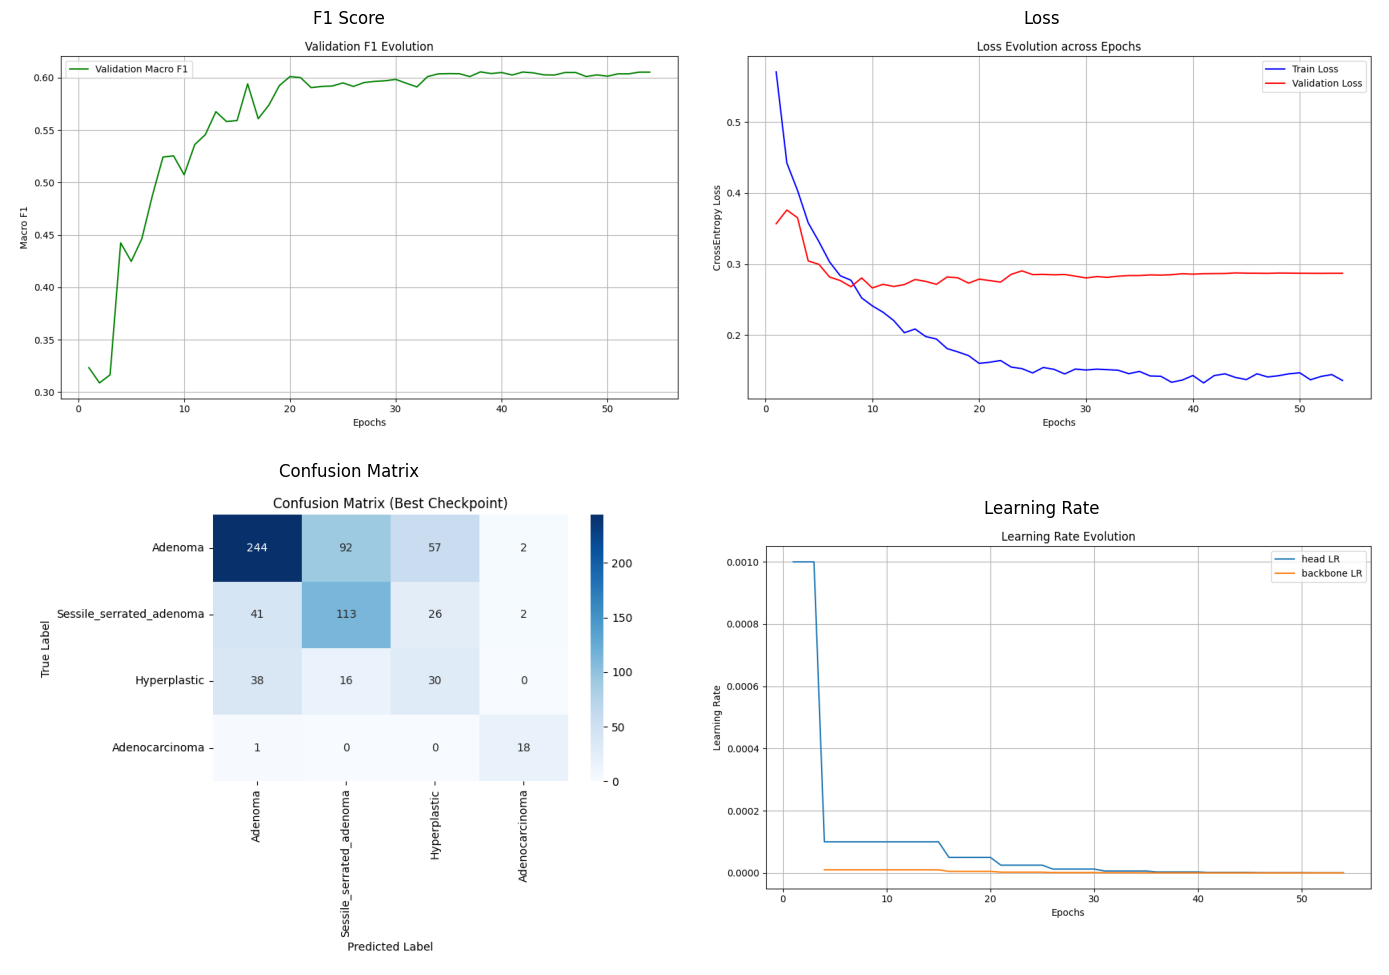

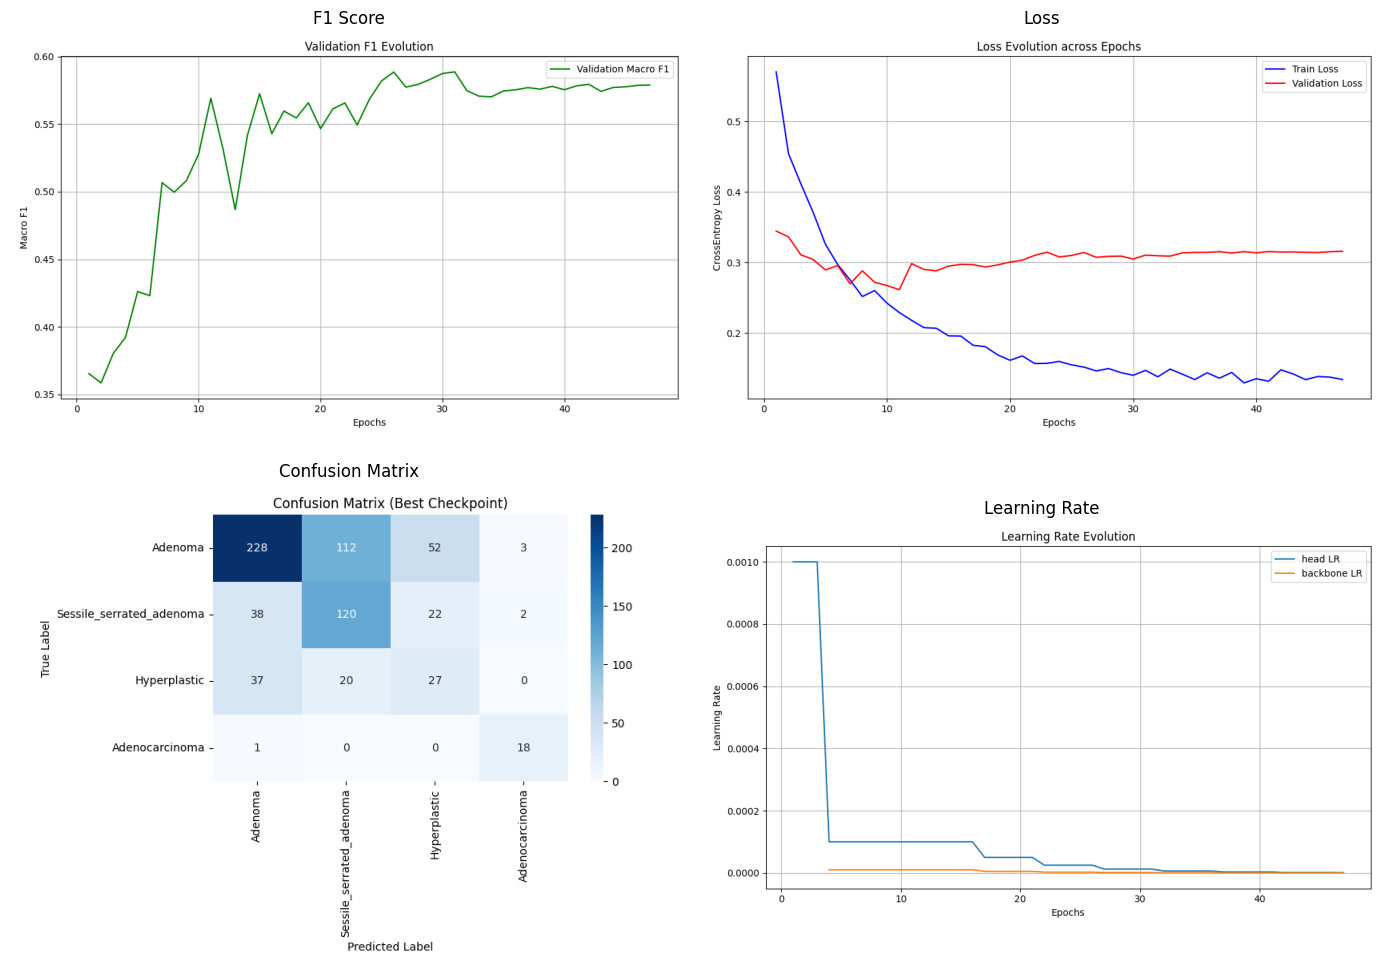

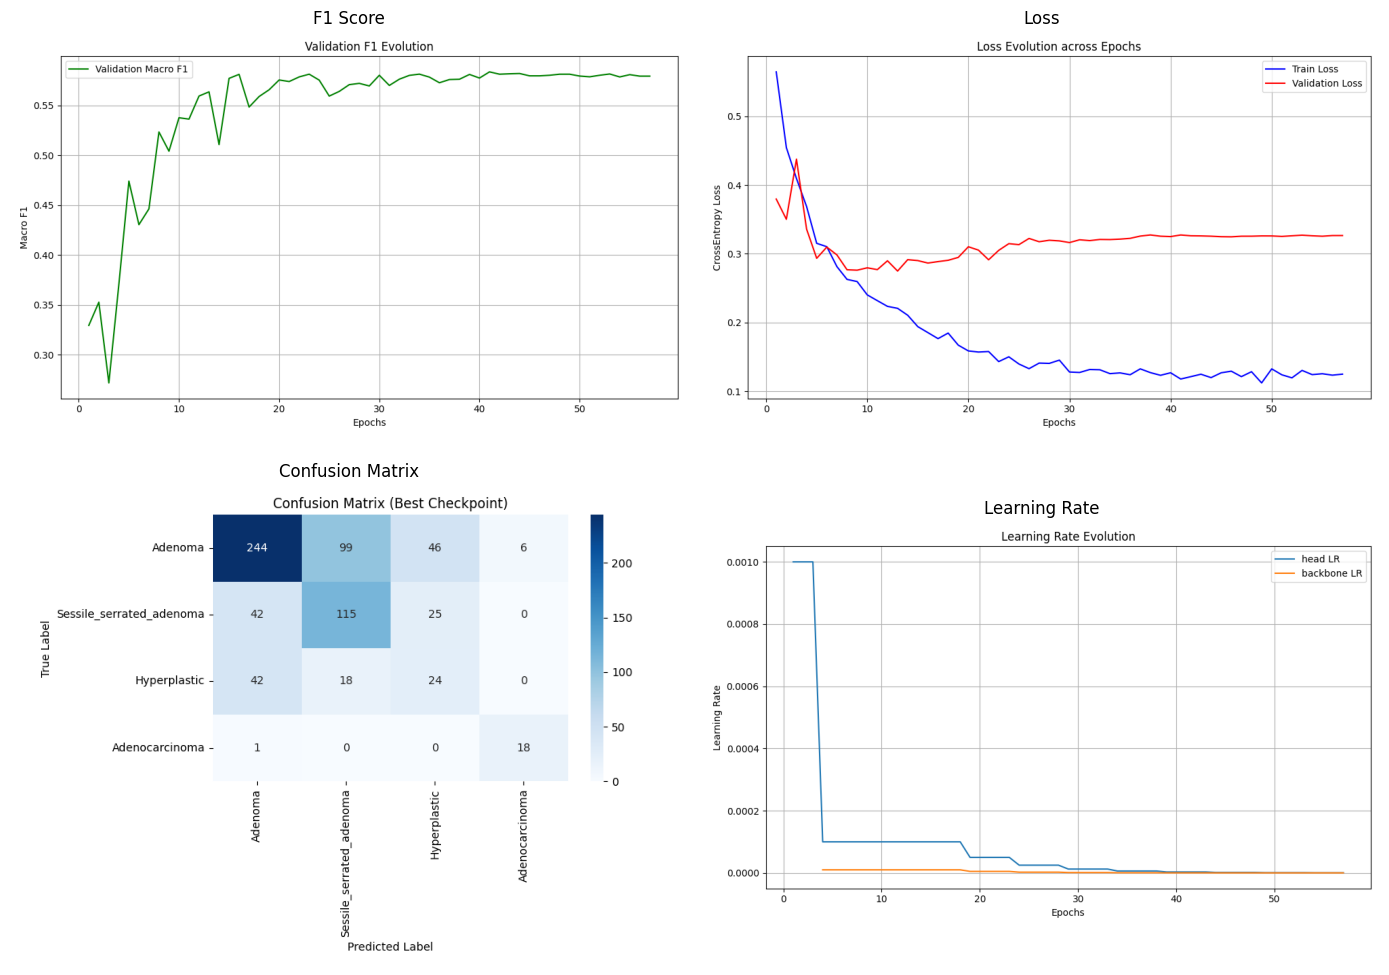

In [4]:
show_phase1_plots(training_config=TRAINING_CONFIG)

In [5]:
print_phase1_summary(training_config=TRAINING_CONFIG)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.5842 +/- 0.0102,0.3344 +/- 0.0086,0.5949 +/- 0.0104,0.5788 +/- 0.0176,0.6263 +/- 0.0068
1,Adenoma,0.6493 +/- 0.0090,0.3162 +/- 0.0117,0.6634 +/- 0.0152,0.7493 +/- 0.0053,0.5956 +/- 0.0258
2,Sessile_serrated_adenoma,0.7276 +/- 0.0103,0.3700 +/- 0.0088,0.5556 +/- 0.0037,0.4937 +/- 0.0144,0.6360 +/- 0.0164
3,Hyperplastic,0.7996 +/- 0.0104,0.1824 +/- 0.0173,0.2940 +/- 0.0190,0.2608 +/- 0.0068,0.3393 +/- 0.0461
4,Adenocarcinoma,0.9919 +/- 0.0019,0.8658 +/- 0.0234,0.8668 +/- 0.0250,0.8114 +/- 0.0622,0.9342 +/- 0.0263


In [6]:
print_results_metrics_summary(
    results_dirs=[run["results_dir"] for run in PHASE1_RUNS],
    validation_csv_dir="test/external_test.csv",
    validation_img_dir="test/images_cropped",
    training_config=TRAINING_CONFIG,
    random_states=[run["random_state"] for run in PHASE1_RUNS],
)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.4910 +/- 0.0083,0.3556 +/- 0.0111,0.4816 +/- 0.0123,0.5570 +/- 0.0152,0.5308 +/- 0.0109
1,Adenoma,0.7204 +/- 0.0015,0.4063 +/- 0.0051,0.6183 +/- 0.0039,0.5618 +/- 0.0017,0.6875 +/- 0.0088
2,Sessile_serrated_adenoma,0.6747 +/- 0.0113,0.2663 +/- 0.0387,0.4056 +/- 0.0250,0.2901 +/- 0.0167,0.6741 +/- 0.0495
3,Hyperplastic,0.6840 +/- 0.0039,0.1552 +/- 0.0210,0.2055 +/- 0.0397,0.6004 +/- 0.0323,0.1250 +/- 0.0291
4,Adenocarcinoma,0.9028 +/- 0.0028,0.6458 +/- 0.0107,0.6972 +/- 0.0170,0.7757 +/- 0.0383,0.6365 +/- 0.0484
